<a href="https://colab.research.google.com/github/sachini9-git/northstar-databases-analytics/blob/main/02_python_service_failure_kpis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Step 1: Python Package Setup and Clean Table Display
# ============================================================
# Purpose:
# Load Python libraries for data processing, KPI creation,
# visualisation, and MongoDB-ready JSON export.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from IPython.display import display, HTML

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

def show_table(df, title="Output Table", max_rows=15):
    html = f"""
    <div style="font-family:Arial; background-color:white; padding:12px;
                border-radius:8px; border:1px solid #BFBFBF; overflow-x:auto;">
        <h3 style="color:#1F4E79; margin-bottom:8px;">{title}</h3>
        {df.head(max_rows).to_html(index=False, border=0)}
    </div>
    <style>
        table {{
            border-collapse: collapse;
            width: 100%;
            font-size: 13px;
            color: black;
            white-space: nowrap;
        }}
        th {{
            background-color: #1F4E79;
            color: white;
            padding: 8px;
            border: 1px solid #BFBFBF;
            text-align: left;
        }}
        td {{
            padding: 8px;
            border: 1px solid #D9D9D9;
            text-align: left;
        }}
        tr:nth-child(even) {{
            background-color: #F2F6FA;
        }}
        tr:nth-child(odd) {{
            background-color: #FFFFFF;
        }}
    </style>
    """
    display(HTML(html))

print("Python packages loaded successfully and clean table function is ready.")

Python packages loaded successfully and clean table function is ready.


In [ ]:
# ============================================================
# Improved Clear Table Display Function
# ============================================================
# Purpose:
# Force clean white/light table rows so screenshots are readable
# even when Google Colab is in dark mode.
# ============================================================

from IPython.display import display, HTML

def show_table(df, title="Output Table", max_rows=15):
    df_display = df.head(max_rows).copy()

    header_html = "".join([
        f"<th style='background-color:#1F4E79;color:white;padding:8px;border:1px solid #BFBFBF;text-align:left;'>{col}</th>"
        for col in df_display.columns
    ])

    rows_html = ""
    for i, (_, row) in enumerate(df_display.iterrows()):
        bg = "#FFFFFF" if i % 2 == 0 else "#F2F6FA"
        rows_html += "<tr>"
        for value in row:
            rows_html += f"<td style='background-color:{bg};color:black;padding:8px;border:1px solid #D9D9D9;text-align:left;white-space:nowrap;'>{value}</td>"
        rows_html += "</tr>"

    html = f"""
    <div style="font-family:Arial; background-color:white; padding:12px;
                border-radius:8px; border:1px solid #BFBFBF; overflow-x:auto;">
        <h3 style="color:#1F4E79; margin-bottom:8px;">{title}</h3>
        <table style="border-collapse:collapse; width:100%; font-size:13px;">
            <thead><tr>{header_html}</tr></thead>
            <tbody>{rows_html}</tbody>
        </table>
    </div>
    """
    display(HTML(html))

print("Improved clean table function is ready.")

Improved clean table function is ready.


In [ ]:
# ============================================================
# Step 2: Import NorthStar Datasets from GitHub
# ============================================================
# Purpose:
# Load all raw CSV files directly from the GitHub repository.
# This makes the Python workflow reproducible.
# ============================================================

base_url = "https://raw.githubusercontent.com/sachini9-git/northstar-databases-analytics/main/data/raw"

customers = pd.read_csv(f"{base_url}/customers.csv")
orders = pd.read_csv(f"{base_url}/orders.csv")
deliveries = pd.read_csv(f"{base_url}/deliveries.csv")
drivers = pd.read_csv(f"{base_url}/drivers.csv")
vehicles = pd.read_csv(f"{base_url}/vehicles.csv")
hubs = pd.read_csv(f"{base_url}/hubs.csv")
incidents = pd.read_csv(f"{base_url}/incidents.csv")
complaints = pd.read_csv(f"{base_url}/complaints.csv")
app_events = pd.read_csv(f"{base_url}/app_events.csv")
data_dictionary = pd.read_csv(f"{base_url}/data_dictionary.csv")

dataset_summary = pd.DataFrame({
    "Dataset": [
        "customers", "orders", "deliveries", "drivers", "vehicles",
        "hubs", "incidents", "complaints", "app_events", "data_dictionary"
    ],
    "Records": [
        len(customers), len(orders), len(deliveries), len(drivers), len(vehicles),
        len(hubs), len(incidents), len(complaints), len(app_events), len(data_dictionary)
    ],
    "Columns": [
        customers.shape[1], orders.shape[1], deliveries.shape[1], drivers.shape[1],
        vehicles.shape[1], hubs.shape[1], incidents.shape[1], complaints.shape[1],
        app_events.shape[1], data_dictionary.shape[1]
    ]
})

show_table(dataset_summary, "Python Dataset Import Summary from GitHub")

Dataset,Records,Columns
customers,650,9
orders,1250,11
deliveries,950,13
drivers,170,8
vehicles,120,8
hubs,8,5
incidents,280,7
complaints,320,10
app_events,640,10
data_dictionary,9,3


In [ ]:
# ============================================================
# Step 3: Dataset Structure and Missing Value Inspection
# ============================================================
# Purpose:
# Check key dataset columns and missing values before merging.
#
# Business justification:
# NorthStar's case problem involves fragmented data, so checking
# structure and missing values helps avoid incorrect KPI creation.
# ============================================================

column_summary = pd.DataFrame({
    "Dataset": ["orders", "deliveries", "customers", "hubs", "complaints", "incidents"],
    "Column_Count": [
        orders.shape[1], deliveries.shape[1], customers.shape[1],
        hubs.shape[1], complaints.shape[1], incidents.shape[1]
    ],
    "Key_Columns": [
        ", ".join(orders.columns),
        ", ".join(deliveries.columns),
        ", ".join(customers.columns),
        ", ".join(hubs.columns),
        ", ".join(complaints.columns),
        ", ".join(incidents.columns)
    ]
})

missing_summary = pd.DataFrame({
    "Dataset": ["orders", "deliveries", "customers", "hubs", "complaints", "incidents"],
    "Total_Missing_Values": [
        orders.isna().sum().sum(),
        deliveries.isna().sum().sum(),
        customers.isna().sum().sum(),
        hubs.isna().sum().sum(),
        complaints.isna().sum().sum(),
        incidents.isna().sum().sum()
    ]
})

show_table(column_summary, "Key Dataset Columns Before Python Processing", max_rows=10)
show_table(missing_summary, "Missing Value Summary Before Processing")

Dataset,Column_Count,Key_Columns
orders,11,"order_id, customer_id, service_type, order_created_at, promised_window_hours, pickup_zone, dropoff_zone, priority_level, order_value, booking_channel, special_handling_flag"
deliveries,13,"delivery_id, order_id, driver_id, vehicle_id, hub_id, dispatch_time, delivery_completed_at, delivery_status, route_distance_km, manual_route_override_count, proof_of_completion_missing, customer_rating_post_delivery, fuel_or_charge_cost"
customers,9,"customer_id, age, home_zone, customer_type, signup_date, loyalty_score, app_engagement_score, preferred_channel, account_status"
hubs,5,"hub_id, hub_name, zone, hub_type, capacity_score"
complaints,10,"complaint_id, customer_id, order_id, complaint_type, channel, severity, created_at, status, resolution_days, compensation_amount"
incidents,7,"incident_id, delivery_id, incident_type, reported_at, severity, resolution_status, resolved_hours"


Dataset,Total_Missing_Values
orders,25
deliveries,33
customers,33
hubs,0
complaints,16
incidents,17


In [ ]:
# ============================================================
# Step 4: Create Integrated Service Dataset
# ============================================================
# Purpose:
# Merge orders, deliveries, customers, hubs, complaints, and incidents
# into one analytical service-level dataset.
#
# Business justification:
# This addresses NorthStar's fragmented data problem by connecting
# customer, order, delivery, hub, complaint, and incident information.
# ============================================================

# Complaint summary at order level
complaint_summary = complaints.groupby("order_id").agg(
    total_complaints=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum"),
    max_complaint_severity=("severity", "max")
).reset_index()

# Incident summary at delivery level
incident_summary = incidents.groupby("delivery_id").agg(
    total_incidents=("incident_id", "count"),
    max_incident_severity=("severity", "max")
).reset_index()

# Merge structured service data
service_data = (
    orders
    .merge(deliveries, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(hubs, on="hub_id", how="left")
    .merge(complaint_summary, on="order_id", how="left")
    .merge(incident_summary, on="delivery_id", how="left")
)

# Replace missing complaint and incident values
service_data["total_complaints"] = service_data["total_complaints"].fillna(0).astype(int)
service_data["total_incidents"] = service_data["total_incidents"].fillna(0).astype(int)
service_data["total_compensation"] = service_data["total_compensation"].fillna(0)
service_data["avg_resolution_days"] = service_data["avg_resolution_days"].fillna(0)

merged_summary = pd.DataFrame({
    "Dataset": ["Integrated service_data"],
    "Records": [service_data.shape[0]],
    "Columns": [service_data.shape[1]]
})

show_table(merged_summary, "Merged Python Service Dataset Summary")

Dataset,Records,Columns
Integrated service_data,1250,41


In [ ]:
# ============================================================
# Step 4B: Display Clean Sample of Integrated Service Dataset
# ============================================================
# Purpose:
# The full merged dataset is too wide for screenshots, so this
# displays only the most important fields.
# ============================================================

key_service_columns = [
    "order_id",
    "customer_id",
    "service_type",
    "pickup_zone",
    "dropoff_zone",
    "delivery_id",
    "delivery_status",
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "hub_name",
    "zone",
    "total_complaints",
    "total_compensation",
    "total_incidents"
]

service_sample = service_data[key_service_columns].head(10)

show_table(
    service_sample,
    "Clean Sample of Integrated Service Dataset",
    max_rows=10
)

order_id,customer_id,service_type,pickup_zone,dropoff_zone,delivery_id,delivery_status,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,hub_name,zone,total_complaints,total_compensation,total_incidents
O00001,C0292,Passenger,Airport,South,DL00937,OnTime,26.65,2.0,4.29,15.82,North Exchange,North,0,0.0,0
O00002,C0459,Passenger,North,AIRPORT,nan,nan,nan,nan,nan,nan,nan,nan,0,0.0,0
O00003,C0161,Passenger,West,AIRPORT,DL00925,Delayed,13.04,2.0,3.7,13.16,South Link,South,1,8.66,0
O00004,C0520,Parcel,RiverSide,North,DL00002,OnTime,10.34,1.0,5.0,13.41,South Link,South,0,0.0,0
O00005,C0558,Retail,Riverside,SOUTH,DL00671,OnTime,16.01,1.0,4.38,13.53,East Dock,East,1,54.41,0
O00006,C0437,Retail,CENTRAL,East,nan,nan,nan,nan,nan,nan,nan,nan,0,0.0,0
O00007,C0001,Business,CENTRAL,Airport,DL00120,Delayed,9.07,1.0,3.93,9.76,Airport Hub,Airport,1,43.9,0
O00008,C0157,Parcel,Riverside,Riverside,DL00201,OnTime,14.08,0.0,5.0,12.87,East Dock,East,1,15.77,0
O00009,C0141,Retail,NORTH,East,DL00042,OnTime,12.02,0.0,4.45,11.41,North Exchange,North,0,0.0,1
O00010,C0171,Retail,South,north,DL00032,OnTime,15.58,1.0,4.23,13.75,Midtown Relay,Central,0,0.0,1


In [ ]:
# ============================================================
# Step 5: Missing Value Handling and Basic Cleaning
# ============================================================
# Purpose:
# Clean important fields before KPI creation by replacing missing
# complaint, incident, delivery and hub values.
#
# Business justification:
# NorthStar has fragmented service data. Missing linked delivery,
# hub or complaint records must be handled carefully before building
# operational risk indicators.
# ============================================================

service_data_clean = service_data.copy()

# Fill missing delivery and hub text fields
service_data_clean["delivery_status"] = service_data_clean["delivery_status"].fillna("No Delivery Record")
service_data_clean["hub_name"] = service_data_clean["hub_name"].fillna("No Linked Hub")
service_data_clean["zone"] = service_data_clean["zone"].fillna("No Linked Zone")

# Fill numeric fields used for KPI creation
numeric_fill_zero = [
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "total_complaints",
    "total_compensation",
    "total_incidents",
    "avg_resolution_days"
]

for col in numeric_fill_zero:
    service_data_clean[col] = service_data_clean[col].fillna(0)

# Keep customer rating missing if no rating exists, but create a display version
service_data_clean["customer_rating_display"] = service_data_clean["customer_rating_post_delivery"].fillna("No Rating")

missing_after_cleaning = pd.DataFrame({
    "Field": [
        "delivery_status",
        "hub_name",
        "zone",
        "route_distance_km",
        "manual_route_override_count",
        "fuel_or_charge_cost",
        "total_complaints",
        "total_incidents"
    ],
    "Missing_After_Cleaning": [
        service_data_clean["delivery_status"].isna().sum(),
        service_data_clean["hub_name"].isna().sum(),
        service_data_clean["zone"].isna().sum(),
        service_data_clean["route_distance_km"].isna().sum(),
        service_data_clean["manual_route_override_count"].isna().sum(),
        service_data_clean["fuel_or_charge_cost"].isna().sum(),
        service_data_clean["total_complaints"].isna().sum(),
        service_data_clean["total_incidents"].isna().sum()
    ]
})

show_table(missing_after_cleaning, "Missing Value Handling After Python Cleaning")

Field,Missing_After_Cleaning
delivery_status,0
hub_name,0
zone,0
route_distance_km,0
manual_route_override_count,0
fuel_or_charge_cost,0
total_complaints,0
total_incidents,0


In [ ]:
# ============================================================
# Step 6: Create Service Failure KPI Flags
# ============================================================
# Purpose:
# Create operational KPI flags that identify failed deliveries,
# delayed deliveries, complaints, incidents, high route overrides,
# high cost, and low customer ratings.
#
# Business justification:
# These KPI flags convert fragmented raw records into clear service
# risk indicators for NorthStar management.
# ============================================================

# Define high-cost threshold using the 75th percentile
high_cost_threshold = service_data_clean["fuel_or_charge_cost"].quantile(0.75)

service_data_clean["is_failed"] = np.where(service_data_clean["delivery_status"] == "Failed", 1, 0)
service_data_clean["is_delayed"] = np.where(service_data_clean["delivery_status"] == "Delayed", 1, 0)
service_data_clean["has_complaint"] = np.where(service_data_clean["total_complaints"] > 0, 1, 0)
service_data_clean["has_incident"] = np.where(service_data_clean["total_incidents"] > 0, 1, 0)
service_data_clean["high_route_override"] = np.where(service_data_clean["manual_route_override_count"] >= 2, 1, 0)
service_data_clean["high_cost"] = np.where(service_data_clean["fuel_or_charge_cost"] > high_cost_threshold, 1, 0)
service_data_clean["low_rating"] = np.where(service_data_clean["customer_rating_post_delivery"] < 3.5, 1, 0)

# Composite risk score
service_data_clean["service_risk_score"] = (
    service_data_clean["is_failed"] * 3 +
    service_data_clean["is_delayed"] * 2 +
    service_data_clean["has_complaint"] * 2 +
    service_data_clean["has_incident"] * 2 +
    service_data_clean["high_route_override"] * 1 +
    service_data_clean["high_cost"] * 1 +
    service_data_clean["low_rating"] * 2
)

# Risk category
service_data_clean["risk_category"] = pd.cut(
    service_data_clean["service_risk_score"],
    bins=[-1, 2, 5, 20],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

kpi_columns = [
    "order_id",
    "service_type",
    "delivery_status",
    "hub_name",
    "zone",
    "is_failed",
    "is_delayed",
    "has_complaint",
    "has_incident",
    "high_route_override",
    "high_cost",
    "low_rating",
    "service_risk_score",
    "risk_category"
]

show_table(
    service_data_clean[kpi_columns].head(15),
    "Service Failure KPI Flags and Risk Score",
    max_rows=15
)

order_id,service_type,delivery_status,hub_name,zone,is_failed,is_delayed,has_complaint,has_incident,high_route_override,high_cost,low_rating,service_risk_score,risk_category
O00001,Passenger,OnTime,North Exchange,North,0,0,0,0,1,1,0,2,Low Risk
O00002,Passenger,No Delivery Record,No Linked Hub,No Linked Zone,0,0,0,0,0,0,0,0,Low Risk
O00003,Passenger,Delayed,South Link,South,0,1,1,0,1,0,0,5,Medium Risk
O00004,Parcel,OnTime,South Link,South,0,0,0,0,0,0,0,0,Low Risk
O00005,Retail,OnTime,East Dock,East,0,0,1,0,0,0,0,2,Low Risk
O00006,Retail,No Delivery Record,No Linked Hub,No Linked Zone,0,0,0,0,0,0,0,0,Low Risk
O00007,Business,Delayed,Airport Hub,Airport,0,1,1,0,0,0,0,4,Medium Risk
O00008,Parcel,OnTime,East Dock,East,0,0,1,0,0,0,0,2,Low Risk
O00009,Retail,OnTime,North Exchange,North,0,0,0,1,0,0,0,2,Low Risk
O00010,Retail,OnTime,Midtown Relay,Central,0,0,0,1,0,0,0,2,Low Risk


In [ ]:
# ============================================================
# Step 6B: Cleaner KPI Table for Report Screenshot
# ============================================================
# Purpose:
# Display only the most important KPI fields so the output is
# readable in the final assignment report.
# ============================================================

kpi_display_columns = [
    "order_id",
    "service_type",
    "delivery_status",
    "hub_name",
    "is_failed",
    "is_delayed",
    "has_complaint",
    "has_incident",
    "service_risk_score",
    "risk_category"
]

show_table(
    service_data_clean[kpi_display_columns].head(15),
    "Clean Service Failure KPI Flags and Risk Score",
    max_rows=15
)

order_id,service_type,delivery_status,hub_name,is_failed,is_delayed,has_complaint,has_incident,service_risk_score,risk_category
O00001,Passenger,OnTime,North Exchange,0,0,0,0,2,Low Risk
O00002,Passenger,No Delivery Record,No Linked Hub,0,0,0,0,0,Low Risk
O00003,Passenger,Delayed,South Link,0,1,1,0,5,Medium Risk
O00004,Parcel,OnTime,South Link,0,0,0,0,0,Low Risk
O00005,Retail,OnTime,East Dock,0,0,1,0,2,Low Risk
O00006,Retail,No Delivery Record,No Linked Hub,0,0,0,0,0,Low Risk
O00007,Business,Delayed,Airport Hub,0,1,1,0,4,Medium Risk
O00008,Parcel,OnTime,East Dock,0,0,1,0,2,Low Risk
O00009,Retail,OnTime,North Exchange,0,0,0,1,2,Low Risk
O00010,Retail,OnTime,Midtown Relay,0,0,0,1,2,Low Risk


In [ ]:
# ============================================================
# Step 7: Hub-Level KPI Summary
# ============================================================
# Purpose:
# Summarise service failure, delay, complaints, incidents, cost,
# and risk score by hub.
#
# Business justification:
# This helps NorthStar identify which hubs create the highest
# operational and customer service risk.
# ============================================================

hub_kpi_summary = (
    service_data_clean
    .groupby(["hub_name", "zone"], as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        failed_deliveries=("is_failed", "sum"),
        delayed_deliveries=("is_delayed", "sum"),
        complaint_cases=("has_complaint", "sum"),
        incident_cases=("has_incident", "sum"),
        avg_route_distance_km=("route_distance_km", "mean"),
        avg_fuel_charge_cost=("fuel_or_charge_cost", "mean"),
        avg_service_risk_score=("service_risk_score", "mean")
    )
)

hub_kpi_summary["failure_rate_percent"] = round(
    100 * hub_kpi_summary["failed_deliveries"] / hub_kpi_summary["total_orders"], 2
)

hub_kpi_summary["delay_rate_percent"] = round(
    100 * hub_kpi_summary["delayed_deliveries"] / hub_kpi_summary["total_orders"], 2
)

hub_kpi_summary["avg_route_distance_km"] = hub_kpi_summary["avg_route_distance_km"].round(2)
hub_kpi_summary["avg_fuel_charge_cost"] = hub_kpi_summary["avg_fuel_charge_cost"].round(2)
hub_kpi_summary["avg_service_risk_score"] = hub_kpi_summary["avg_service_risk_score"].round(2)

hub_kpi_summary = hub_kpi_summary.sort_values(
    by="avg_service_risk_score",
    ascending=False
)

show_table(
    hub_kpi_summary,
    "Python Hub-Level Service Risk KPI Summary",
    max_rows=12
)

hub_name,zone,total_orders,failed_deliveries,delayed_deliveries,complaint_cases,incident_cases,avg_route_distance_km,avg_fuel_charge_cost,avg_service_risk_score,failure_rate_percent,delay_rate_percent
Central Core,Central,115,23,25,28,34,14.32,13.69,3.47,20.0,21.74
Midtown Relay,Central,128,26,22,31,32,12.82,11.71,3.04,20.31,17.19
Airport Hub,Airport,104,15,27,21,25,14.41,13.32,3.02,14.42,25.96
Riverside Hub,Riverside,115,14,25,30,32,14.29,12.92,3.0,12.17,21.74
West Gate,West,127,16,28,26,33,13.38,13.17,2.87,12.6,22.05
East Dock,East,119,11,23,31,32,14.52,12.74,2.72,9.24,19.33
North Exchange,North,136,17,26,26,30,13.64,12.76,2.71,12.5,19.12
South Link,South,106,10,26,16,30,14.17,12.57,2.71,9.43,24.53
No Linked Hub,No Linked Zone,300,0,0,76,0,0.0,0.0,0.51,0.0,0.0


In [ ]:
# ============================================================
# Step 8: Service-Type KPI Summary
# ============================================================
# Purpose:
# Summarise failure, delay, complaints, compensation and risk score
# by service type.
#
# Business justification:
# This helps NorthStar identify which service types create the most
# operational pressure and customer dissatisfaction.
# ============================================================

service_type_kpi_summary = (
    service_data_clean
    .groupby("service_type", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        failed_deliveries=("is_failed", "sum"),
        delayed_deliveries=("is_delayed", "sum"),
        complaint_cases=("has_complaint", "sum"),
        incident_cases=("has_incident", "sum"),
        total_compensation=("total_compensation", "sum"),
        avg_fuel_charge_cost=("fuel_or_charge_cost", "mean"),
        avg_service_risk_score=("service_risk_score", "mean")
    )
)

service_type_kpi_summary["failure_rate_percent"] = round(
    100 * service_type_kpi_summary["failed_deliveries"] / service_type_kpi_summary["total_orders"], 2
)

service_type_kpi_summary["delay_rate_percent"] = round(
    100 * service_type_kpi_summary["delayed_deliveries"] / service_type_kpi_summary["total_orders"], 2
)

service_type_kpi_summary["complaint_rate_percent"] = round(
    100 * service_type_kpi_summary["complaint_cases"] / service_type_kpi_summary["total_orders"], 2
)

service_type_kpi_summary["total_compensation"] = service_type_kpi_summary["total_compensation"].round(2)
service_type_kpi_summary["avg_fuel_charge_cost"] = service_type_kpi_summary["avg_fuel_charge_cost"].round(2)
service_type_kpi_summary["avg_service_risk_score"] = service_type_kpi_summary["avg_service_risk_score"].round(2)

service_type_kpi_summary = service_type_kpi_summary.sort_values(
    by="avg_service_risk_score",
    ascending=False
)

show_table(
    service_type_kpi_summary,
    "Python Service-Type Risk and Compensation KPI Summary",
    max_rows=10
)

service_type,total_orders,failed_deliveries,delayed_deliveries,complaint_cases,incident_cases,total_compensation,avg_fuel_charge_cost,avg_service_risk_score,failure_rate_percent,delay_rate_percent,complaint_rate_percent
Business,165,25,28,34,41,810.86,10.04,2.62,15.15,16.97,20.61
Retail,297,28,50,72,66,1486.14,9.79,2.42,9.43,16.84,24.24
Medical,139,16,22,33,23,740.01,9.92,2.34,11.51,15.83,23.74
Passenger,341,38,53,77,62,1657.53,9.53,2.28,11.14,15.54,22.58
Parcel,308,25,49,69,56,1463.65,9.77,2.24,8.12,15.91,22.4


In [ ]:
# ============================================================
# Step 9: Clean Python Chart Style
# ============================================================
# Purpose:
# Prepare a consistent clean style for Python visualisations.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = "python_outputs"
os.makedirs(output_dir, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelsize": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

print("Clean Python chart style and output folder are ready.")

Clean Python chart style and output folder are ready.


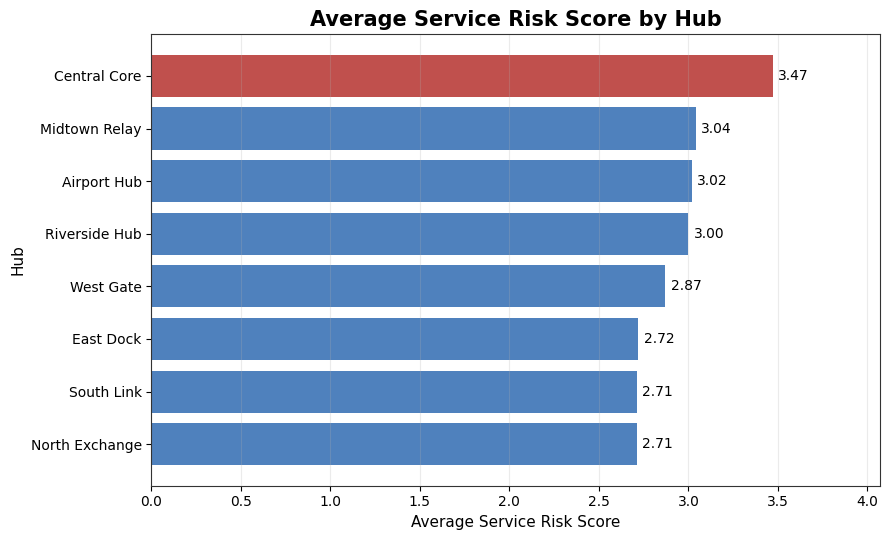

In [ ]:
# ============================================================
# Step 10: Python Visualisation 1 - Hub Service Risk Bar Chart
# ============================================================
# Purpose:
# Visualise average service risk score by hub using a sorted
# horizontal bar chart.
#
# Business justification:
# This helps NorthStar identify which hubs should be prioritised
# for operational review based on average service risk score.
# ============================================================

hub_chart_data = hub_kpi_summary[hub_kpi_summary["hub_name"] != "No Linked Hub"].copy()
hub_chart_data = hub_chart_data.sort_values("avg_service_risk_score", ascending=True)

bar_colors = [
    "#C0504D" if value == hub_chart_data["avg_service_risk_score"].max() else "#4F81BD"
    for value in hub_chart_data["avg_service_risk_score"]
]

plt.figure(figsize=(9, 5.5))

bars = plt.barh(
    hub_chart_data["hub_name"],
    hub_chart_data["avg_service_risk_score"],
    color=bar_colors
)

plt.title("Average Service Risk Score by Hub")
plt.xlabel("Average Service Risk Score")
plt.ylabel("Hub")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.25)
plt.xlim(0, hub_chart_data["avg_service_risk_score"].max() + 0.6)

plt.tight_layout()
plt.savefig("python_outputs/hub_service_risk_score.png", dpi=200, bbox_inches="tight")
plt.show()

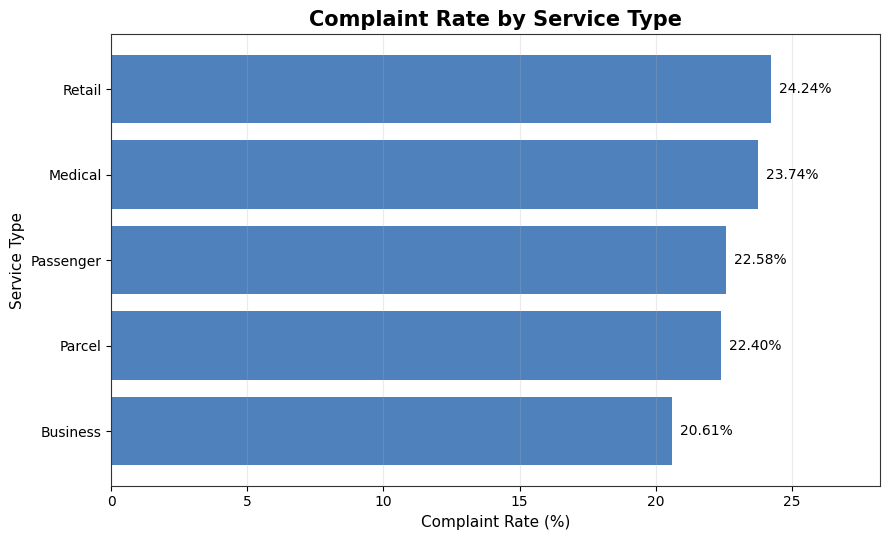

In [ ]:
# ============================================================
# Step 11: Python Visualisation 2 - Complaint Rate by Service Type
# ============================================================
# Purpose:
# Show which service types create the highest customer complaint rate.
#
# Business justification:
# This helps NorthStar identify where customer dissatisfaction is
# concentrated across service categories.
# ============================================================

complaint_chart = service_type_kpi_summary.sort_values(
    "complaint_rate_percent",
    ascending=True
)

plt.figure(figsize=(9, 5.5))

bars = plt.barh(
    complaint_chart["service_type"],
    complaint_chart["complaint_rate_percent"],
    color="#4F81BD"
)

plt.title("Complaint Rate by Service Type")
plt.xlabel("Complaint Rate (%)")
plt.ylabel("Service Type")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.25)
plt.xlim(0, complaint_chart["complaint_rate_percent"].max() + 4)

plt.tight_layout()
plt.savefig("python_outputs/service_type_complaint_rate.png", dpi=200, bbox_inches="tight")
plt.show()

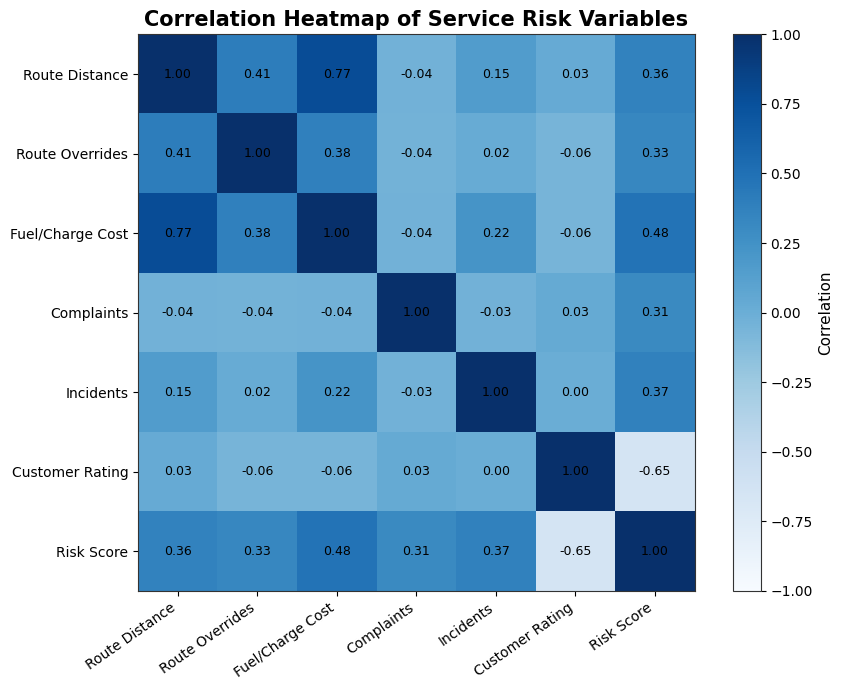

In [ ]:
# ============================================================
# Step 12: Python Visualisation 3 - Correlation Heatmap
# ============================================================
# Purpose:
# Show relationships between service risk variables using short labels.
#
# Business justification:
# This helps identify which operational variables are associated
# with higher service risk.
# ============================================================

corr_columns = [
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "total_complaints",
    "total_incidents",
    "customer_rating_post_delivery",
    "service_risk_score"
]

corr_labels = [
    "Route Distance",
    "Route Overrides",
    "Fuel/Charge Cost",
    "Complaints",
    "Incidents",
    "Customer Rating",
    "Risk Score"
]

corr_matrix = service_data_clean[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(9, 7))

heatmap = plt.imshow(corr_matrix, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(heatmap, label="Correlation")

plt.title("Correlation Heatmap of Service Risk Variables")
plt.xticks(range(len(corr_labels)), corr_labels, rotation=35, ha="right")
plt.yticks(range(len(corr_labels)), corr_labels)

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.tight_layout()
plt.savefig("python_outputs/service_risk_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

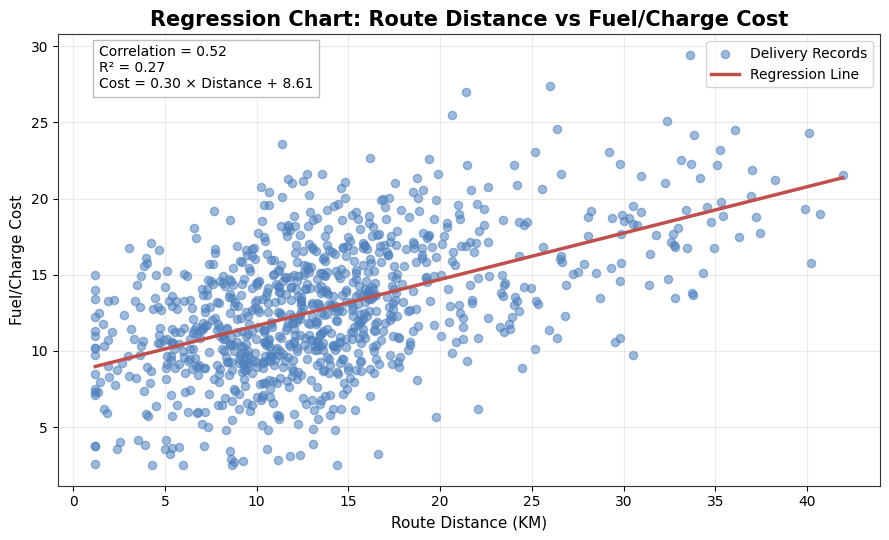

In [ ]:
# ============================================================
# Step 13: Python Regression Chart - Route Distance vs Fuel/Charge Cost
# ============================================================
# Purpose:
# Create a regression chart to examine whether route distance predicts
# fuel/charge cost.
#
# Business justification:
# Longer delivery routes may increase operational cost. This regression
# chart helps NorthStar understand the relationship between route distance
# and fuel/charge cost.
# ============================================================

scatter_data = service_data_clean[
    service_data_clean["delivery_status"].isin(["OnTime", "Delayed", "Failed"])
].copy()

# Remove zero values created from missing delivery records
scatter_data = scatter_data[
    (scatter_data["route_distance_km"] > 0) &
    (scatter_data["fuel_or_charge_cost"] > 0)
]

x = scatter_data["route_distance_km"]
y = scatter_data["fuel_or_charge_cost"]

# Correlation and simple regression
correlation_value = x.corr(y)
slope, intercept = np.polyfit(x, y, 1)
r_squared = correlation_value ** 2

x_sorted = np.sort(x)
trend_line = slope * x_sorted + intercept

plt.figure(figsize=(9, 5.5))

plt.scatter(
    x,
    y,
    alpha=0.55,
    s=35,
    color="#4F81BD",
    label="Delivery Records"
)

plt.plot(
    x_sorted,
    trend_line,
    color="#C0504D",
    linewidth=2.5,
    label="Regression Line"
)

plt.title("Regression Chart: Route Distance vs Fuel/Charge Cost")
plt.xlabel("Route Distance (KM)")
plt.ylabel("Fuel/Charge Cost")
plt.grid(alpha=0.25)
plt.legend()

equation_text = (
    f"Correlation = {correlation_value:.2f}\n"
    f"R² = {r_squared:.2f}\n"
    f"Cost = {slope:.2f} × Distance + {intercept:.2f}"
)

plt.text(
    0.05,
    0.88,
    equation_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="#BFBFBF")
)

plt.tight_layout()
plt.savefig("python_outputs/route_distance_cost_regression_chart.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Step 13B: Regression Summary Table
# ============================================================
# Purpose:
# Summarise the regression relationship between route distance and
# fuel/charge cost.
#
# Business justification:
# This table supports the regression chart by showing correlation,
# R-squared, slope and interpretation.
# ============================================================

regression_summary = pd.DataFrame({
    "Analysis": ["Route Distance predicting Fuel/Charge Cost"],
    "Correlation": [round(correlation_value, 2)],
    "R_Squared": [round(r_squared, 2)],
    "Slope": [round(slope, 2)],
    "Intercept": [round(intercept, 2)],
    "Interpretation": [
        "Moderate positive relationship; longer routes are generally linked with higher fuel/charge cost."
    ]
})

show_table(
    regression_summary,
    "Simple Regression Summary: Route Distance and Fuel/Charge Cost"
)

Analysis,Correlation,R_Squared,Slope,Intercept,Interpretation
Route Distance predicting Fuel/Charge Cost,0.52,0.27,0.3,8.61,Moderate positive relationship; longer routes are generally linked with higher fuel/charge cost.


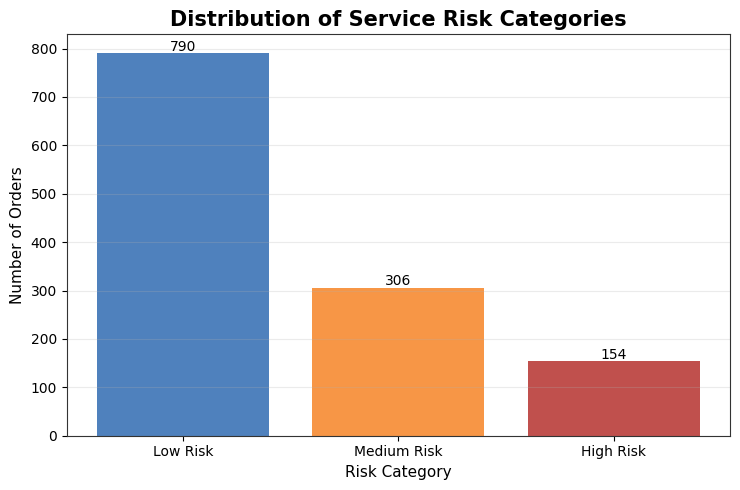

In [ ]:
# ============================================================
# Step 14: Python Visualisation 5 - Risk Category Distribution
# ============================================================
# Purpose:
# Show the number of service records in each risk category.
#
# Business justification:
# This summarises how many NorthStar service records are low,
# medium or high risk after KPI scoring.
# ============================================================

risk_counts = (
    service_data_clean["risk_category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .fillna(0)
)

plt.figure(figsize=(7.5, 5))

bars = plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values,
    color=["#4F81BD", "#F79646", "#C0504D"]
)

plt.title("Distribution of Service Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Orders")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("python_outputs/risk_category_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Step 15: Export Processed Service KPI Dataset to CSV
# ============================================================
# Purpose:
# Save the cleaned and enriched service dataset as a processed CSV.
#
# Business justification:
# This creates a reusable processed dataset for reporting and future
# database loading.
# ============================================================

processed_csv_path = "python_outputs/northstar_service_failure_kpis.csv"

service_data_clean.to_csv(processed_csv_path, index=False)

export_summary = pd.DataFrame({
    "Output_File": [processed_csv_path],
    "Records_Exported": [service_data_clean.shape[0]],
    "Columns_Exported": [service_data_clean.shape[1]]
})

show_table(export_summary, "Processed CSV Export Summary")

Output_File,Records_Exported,Columns_Exported
python_outputs/northstar_service_failure_kpis.csv,1250,51


In [ ]:
# ============================================================
# Step 16: Export MongoDB-Ready JSON Service Case File
# ============================================================
# Purpose:
# Create a semi-structured JSON file suitable for loading into MongoDB.
#
# Business justification:
# This supports the NoSQL part of the assignment by reshaping the
# integrated service dataset into document-style service case records.
# ============================================================

mongo_columns = [
    "order_id",
    "customer_id",
    "service_type",
    "pickup_zone",
    "dropoff_zone",
    "delivery_id",
    "delivery_status",
    "hub_name",
    "zone",
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "total_complaints",
    "total_compensation",
    "total_incidents",
    "is_failed",
    "is_delayed",
    "has_complaint",
    "has_incident",
    "high_route_override",
    "high_cost",
    "low_rating",
    "service_risk_score",
    "risk_category"
]

mongo_ready = service_data_clean[mongo_columns].copy()

mongo_ready["risk_category"] = mongo_ready["risk_category"].astype(str)

mongo_ready = mongo_ready.replace({np.nan: None})

json_records = mongo_ready.to_dict(orient="records")

json_path = "python_outputs/northstar_service_cases_mongodb.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(json_records, f, indent=2, default=str)

json_export_summary = pd.DataFrame({
    "Output_File": [json_path],
    "Documents_Exported": [len(json_records)],
    "Purpose": ["MongoDB-ready service case documents"]
})

show_table(json_export_summary, "MongoDB-Ready JSON Export Summary")

Output_File,Documents_Exported,Purpose
python_outputs/northstar_service_cases_mongodb.json,1250,MongoDB-ready service case documents


In [ ]:
# ============================================================
# Step 17: Basic NumPy Statistical Analysis
# ============================================================
# Purpose:
# Calculate descriptive statistics for key operational numeric fields.
#
# Business justification:
# This provides a statistical overview of route distance, cost,
# customer ratings, and risk score before moving into MongoDB.
# ============================================================

stats_data = service_data_clean[
    (service_data_clean["route_distance_km"] > 0) &
    (service_data_clean["fuel_or_charge_cost"] > 0)
].copy()

basic_stats = pd.DataFrame({
    "Metric": [
        "Route Distance KM",
        "Fuel/Charge Cost",
        "Customer Rating",
        "Service Risk Score"
    ],
    "Mean": [
        np.mean(stats_data["route_distance_km"]),
        np.mean(stats_data["fuel_or_charge_cost"]),
        np.nanmean(stats_data["customer_rating_post_delivery"]),
        np.mean(stats_data["service_risk_score"])
    ],
    "Median": [
        np.median(stats_data["route_distance_km"]),
        np.median(stats_data["fuel_or_charge_cost"]),
        np.nanmedian(stats_data["customer_rating_post_delivery"]),
        np.median(stats_data["service_risk_score"])
    ],
    "Standard_Deviation": [
        np.std(stats_data["route_distance_km"]),
        np.std(stats_data["fuel_or_charge_cost"]),
        np.nanstd(stats_data["customer_rating_post_delivery"]),
        np.std(stats_data["service_risk_score"])
    ]
})

basic_stats["Mean"] = basic_stats["Mean"].round(2)
basic_stats["Median"] = basic_stats["Median"].round(2)
basic_stats["Standard_Deviation"] = basic_stats["Standard_Deviation"].round(2)

show_table(
    basic_stats,
    "Python Basic Statistical Analysis Using NumPy"
)

Metric,Mean,Median,Standard_Deviation
Route Distance KM,13.91,12.84,7.47
Fuel/Charge Cost,12.84,12.64,4.33
Customer Rating,3.86,4.04,0.89
Service Risk Score,2.94,2.0,2.28


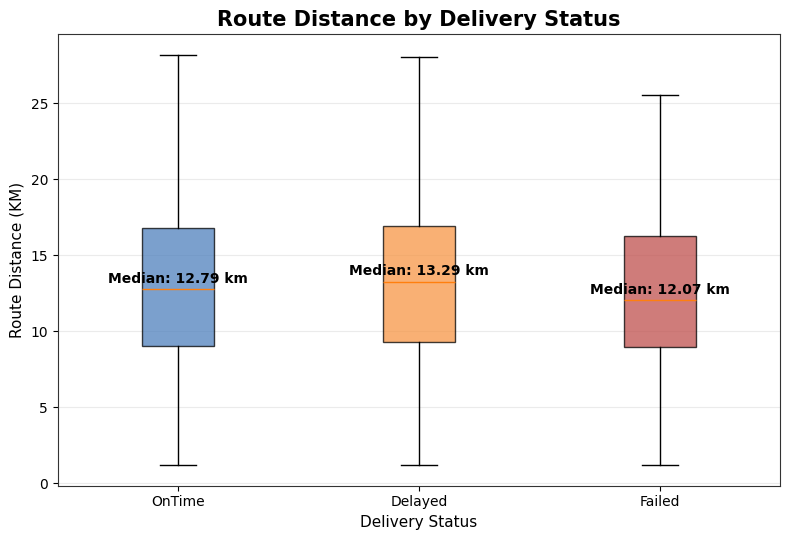

In [ ]:
# ============================================================
# Step 18: Python Visualisation - Route Distance by Delivery Status
# ============================================================
# Purpose:
# Compare route distance distributions for OnTime, Delayed and Failed
# deliveries using a clean boxplot.
#
# Business justification:
# This helps identify whether delayed or failed deliveries are linked
# with longer or more variable delivery routes.
# ============================================================

boxplot_data = service_data_clean[
    service_data_clean["delivery_status"].isin(["OnTime", "Delayed", "Failed"])
].copy()

boxplot_data = boxplot_data[boxplot_data["route_distance_km"] > 0]

status_order = ["OnTime", "Delayed", "Failed"]

boxplot_values = [
    boxplot_data[boxplot_data["delivery_status"] == status]["route_distance_km"]
    for status in status_order
]

plt.figure(figsize=(8, 5.5))

box = plt.boxplot(
    boxplot_values,
    tick_labels=status_order,
    patch_artist=True,
    showfliers=False
)

colors = ["#4F81BD", "#F79646", "#C0504D"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Add median labels
for i, status in enumerate(status_order, start=1):
    median_value = boxplot_data[
        boxplot_data["delivery_status"] == status
    ]["route_distance_km"].median()

    plt.text(
        i,
        median_value + 0.4,
        f"Median: {median_value:.2f} km",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Route Distance by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Route Distance (KM)")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("python_outputs/route_distance_by_delivery_status_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

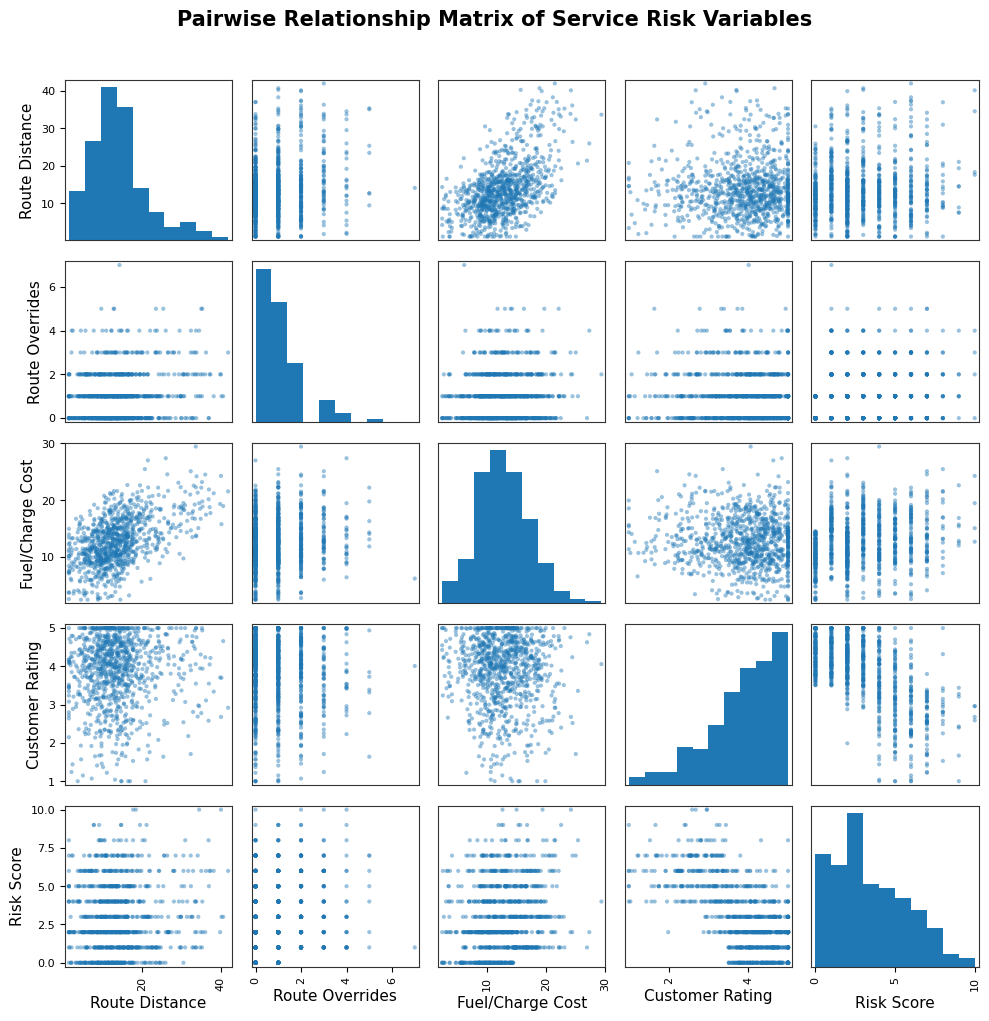

In [ ]:
# ============================================================
# Extra Python Visualisation: Pairwise Relationship Matrix
# ============================================================
# Purpose:
# Show pairwise relationships between key operational variables.
#
# Business justification:
# This supports relationship analysis by comparing route distance,
# route overrides, fuel/charge cost, customer rating and service risk.
# ============================================================

from pandas.plotting import scatter_matrix

pairplot_data = service_data_clean[
    [
        "route_distance_km",
        "manual_route_override_count",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery",
        "service_risk_score"
    ]
].copy()

# Remove records with missing or zero operational values for clearer plotting
pairplot_data = pairplot_data[
    (pairplot_data["route_distance_km"] > 0) &
    (pairplot_data["fuel_or_charge_cost"] > 0)
]

pairplot_data = pairplot_data.dropna()

# Rename columns for clearer chart labels
pairplot_data = pairplot_data.rename(columns={
    "route_distance_km": "Route Distance",
    "manual_route_override_count": "Route Overrides",
    "fuel_or_charge_cost": "Fuel/Charge Cost",
    "customer_rating_post_delivery": "Customer Rating",
    "service_risk_score": "Risk Score"
})

axes = scatter_matrix(
    pairplot_data,
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.45
)

plt.suptitle(
    "Pairwise Relationship Matrix of Service Risk Variables",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig("python_outputs/pairwise_relationship_matrix.png", dpi=200, bbox_inches="tight")
plt.show()